In [27]:
import pandas as pd

# =========================
# Load Dataset
# =========================

df = pd.read_csv("C:\\Users\\KARUN NAGARAJ\\Downloads\\MLLAB\\LAB3\\Student Awareness Survey (Responses) - Form Responses 1.csv")

# =========================
# First 5 Rows
# =========================

print("First 5 Rows")
print(df.head())

# =========================
# Dataset Dimensions
# =========================

print("\nDataset Shape")
print(df.shape)

# =========================
# Missing Values
# =========================

print("\nMissing Values")
print(df.isnull().sum())

# =========================
# Convert Required Columns
# =========================

numeric_columns = [
    'What is the minimum salary of students placed through campus (In LPA..respond as a number)',
    'What is the maximum salary of students placed through campus (In LPA..respond as a number)',
    'Rate your contribution towards extra curricular activities',
    'Rate your technical competencies',
    'What are your package expectations (LPA)',
    'Your CIA % of last semester',
    'Your GPA of last semester',
    'Your maximum attendance % till last semester'
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# =========================
# Remove Null Values
# =========================

df = df.dropna()

# =========================
# Remove Duplicates
# =========================

print("\nDuplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

# =========================
# Data Types
# =========================

print("\nData Types")
print(df.dtypes)

# =========================
# Statistical Summary
# =========================

print("\nStatistical Summary")
print(df.describe())

# =========================
# Variables for Regression
# =========================

# Experiment 1
X1 = df[['Your CIA % of last semester']]
Y1 = df['Your GPA of last semester']

# Experiment 2
X2 = df[['Your maximum attendance % till last semester']]
Y2 = df['Your GPA of last semester']

print("\nExperiment 1")
print("X =", X1.columns[0])
print("Y =", Y1.name)

print("\nExperiment 2")
print("X =", X2.columns[0])
print("Y =", Y2.name)

First 5 Rows
           Timestamp  Registration Number  \
0  6/15/2026 9:25:39              2547231   
1  6/15/2026 9:53:54              2547237   
2  6/15/2026 9:54:56              2547203   
3  6/15/2026 9:55:17              2547228   
4  6/15/2026 9:55:42              2547241   

                                        Email  \
0       kunnal.kunnal@mca.christuniversity.in   
1  omkaar.chakraborty@mca.christuniversity.in   
2        abhinav.jain@mca.christuniversity.in   
3          jai.pareek@mca.christuniversity.in   
4             r.karan@mca.christuniversity.in   

   Job role that you are interested in  \
0  Software Development Engineer (SDE)   
1  Software Development Engineer (SDE)   
2                 Full Stack Developer   
3                 Full Stack Developer   
4  Software Development Engineer (SDE)   

  What is the minimum salary of students placed through campus (In LPA..respond as a number)  \
0                                                3.5                    

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


# Experiment 1
# X = CIA Percentage
# Y = GPA


X = df[['Your CIA % of last semester']]
Y = df['Your GPA of last semester']


# Train-Test Split
# 80% Training
# 20% Testing

x1train, x1test, y1train, y1test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

print("Training Samples :", len(x1train))
print("Testing Samples  :", len(x1test))


# Create Linear Regression Model
model = LinearRegression()


# Train Model
model.fit(x1train, y1train)


# Obtain Slope and Intercept
slope = model.coef_[0]
intercept = model.intercept_

print("\nSlope (m) =", slope)
print("Intercept (b) =", intercept)


# Regression Equation
print(f"\nRegression Equation:")
print(f"GPA = ({slope:.4f}) * CIA + ({intercept:.4f})")


# Predict GPA on Test Data
Y_pred_1 = model.predict(x1test)


# Display Actual vs Predicted
results = x1test.copy()

results['Actual GPA'] = y1test.values
results['Predicted GPA'] = Y_pred_1

print("\nPredictions")
print(results.head(10))

Training Samples : 24
Testing Samples  : 7

Slope (m) = 0.011126051758389743
Intercept (b) = 2.5937416949399195

Regression Equation:
GPA = (0.0111) * CIA + (2.5937)

Predictions
    Your CIA % of last semester  Actual GPA  Predicted GPA
41                         75.2        3.54       3.430421
18                         64.0        3.11       3.305809
35                         71.0        3.40       3.383691
26                         70.0        3.40       3.372565
8                          73.0        3.60       3.405943
9                          79.0        3.73       3.472700
46                         70.0        3.69       3.372565


Every 1% increase in CIA increases GPA by approximately 0.0111% 
Mathematically:

If a student had 0% CIA, the model predicts a GPA of about 2.59.

Practically, this value is not very meaningful because nobody in the dataset likely has CIA = 0.

The intercept mainly helps position the regression line correctly.

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


# Experiment 2
# X = Attendance Percentage
# Y = GPA


X = df[['Your maximum attendance % till last semester']]
Y = df['Your GPA of last semester']


# Train-Test Split


x2train, x2test, y2train, y2test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

print("Training Samples :", len(x2train))
print("Testing Samples  :", len(x2test))


# Create and Train Model
model = LinearRegression()

model.fit(x2train, y2train)


# Slope and Intercept


slope = model.coef_[0]
intercept = model.intercept_

print("\nSlope (m) =", slope)
print("Intercept (b) =", intercept)


# Regression Equation


print("\nRegression Equation:")
print(f"GPA = ({slope:.4f}) * Attendance + ({intercept:.4f})")


# Predictions


Y_pred_2 = model.predict(x2test)

results = x2test.copy()

results['Actual GPA'] = y2test.values
results['Predicted GPA'] = Y_pred_2

print("\nPredictions")
print(results.head(10))

Training Samples : 24
Testing Samples  : 7

Slope (m) = 0.023105590062111804
Intercept (b) = 1.2289648033126288

Regression Equation:
GPA = (0.0231) * Attendance + (1.2290)

Predictions
    Your maximum attendance % till last semester  Actual GPA  Predicted GPA
41                                          96.0        3.54       3.447101
18                                         100.0        3.11       3.539524
35                                          88.0        3.40       3.262257
26                                          96.0        3.40       3.447101
8                                           90.0        3.60       3.308468
9                                           93.0        3.73       3.377785
46                                          97.0        3.69       3.470207


For every 1% increase in attendance, the GPA is expected to increase by approximately: 0.0231

Attendance = 100
Actual GPA = 3.11
Predicted GPA = 3.540

Error:

3.11−3.54=−0.43

The model overestimated this student's GPA.

This suggests attendance alone cannot fully explain GPA.

The positive slope indicates a positive relationship between attendance and GPA. As attendance increases, GPA tends to increase. The predicted GPA values are reasonably close to the actual GPA values, suggesting that attendance can be used as a predictor of academic performance. When compared with the CIA-based model, the attendance model produced a larger slope value, indicating a stronger linear relationship with GPA in the collected dataset.

In [30]:
import numpy as np
import pandas as pd


# Experiment 1
# X = CIA
# Y = GPA


x = df['Your CIA % of last semester']
y = df['Your GPA of last semester']

# Mean values
x_mean = np.mean(x)
y_mean = np.mean(y)

# Numerator of slope
numerator = np.sum((x - x_mean) * (y - y_mean))

# Denominator of slope
denominator = np.sum((x - x_mean) ** 2)

# Slope (m)
m = numerator / denominator

# Intercept (b)
b = y_mean - (m * x_mean)

print("Manual OLS Results")
print("Slope (m) =", m)
print("Intercept (b) =", b)

print("\nManual Regression Equation:")
print(f"GPA = ({m:.6f}) * CIA + ({b:.6f})")

Manual OLS Results
Slope (m) = 0.013348495186275846
Intercept (b) = 2.4554515644711734

Manual Regression Equation:
GPA = (0.013348) * CIA + (2.455452)


In [31]:
# Manual Predictions

y_pred_manual = m * x1test['Your CIA % of last semester'] + b

comparison = pd.DataFrame({
    'CIA': x1test['Your CIA % of last semester'],
    'Actual GPA': y1test,
    'Manual Prediction': y_pred_manual
})

print(comparison.head(10))

     CIA  Actual GPA  Manual Prediction
41  75.2        3.54           3.459258
18  64.0        3.11           3.309755
35  71.0        3.40           3.403195
26  70.0        3.40           3.389846
8   73.0        3.60           3.429892
9   79.0        3.73           3.509983
46  70.0        3.69           3.389846


In [32]:
comparison = pd.DataFrame({
    'CIA': x1test['Your CIA % of last semester'],
    'Actual GPA': y1test,
    'Scikit Prediction': Y_pred_1,
    'Manual Prediction': y_pred_manual
})

comparison['Difference'] = abs(
    comparison['Scikit Prediction']
    - comparison['Manual Prediction']
)

print(comparison)

     CIA  Actual GPA  Scikit Prediction  Manual Prediction  Difference
41  75.2        3.54           3.430421           3.459258    0.028838
18  64.0        3.11           3.305809           3.309755    0.003946
35  71.0        3.40           3.383691           3.403195    0.019503
26  70.0        3.40           3.372565           3.389846    0.017281
8   73.0        3.60           3.405943           3.429892    0.023948
9   79.0        3.73           3.472700           3.509983    0.037283
46  70.0        3.69           3.372565           3.389846    0.017281


The predictions obtained from the manually computed OLS regression equation were compared with the predictions generated by Scikit-learn's LinearRegression model. Both methods produced very similar results, with differences ranging from approximately 0.004 to 0.037 GPA points. These differences occurred because the manual OLS computation was performed using the entire dataset, whereas the Scikit-learn model was trained only on the training subset. Despite this, both approaches demonstrated the same underlying linear relationship between CIA percentage and GPA. The results confirm that Scikit-learn's LinearRegression implementation is based on the Ordinary Least Squares (OLS) method.

The manual OLS calculation was performed on the entire dataset, while Scikit-learn was trained only on the training data after the train-test split. Since the parameters were learned from different data subsets, small differences appeared in the predictions. If both methods are trained on the same data, the predictions become nearly identical

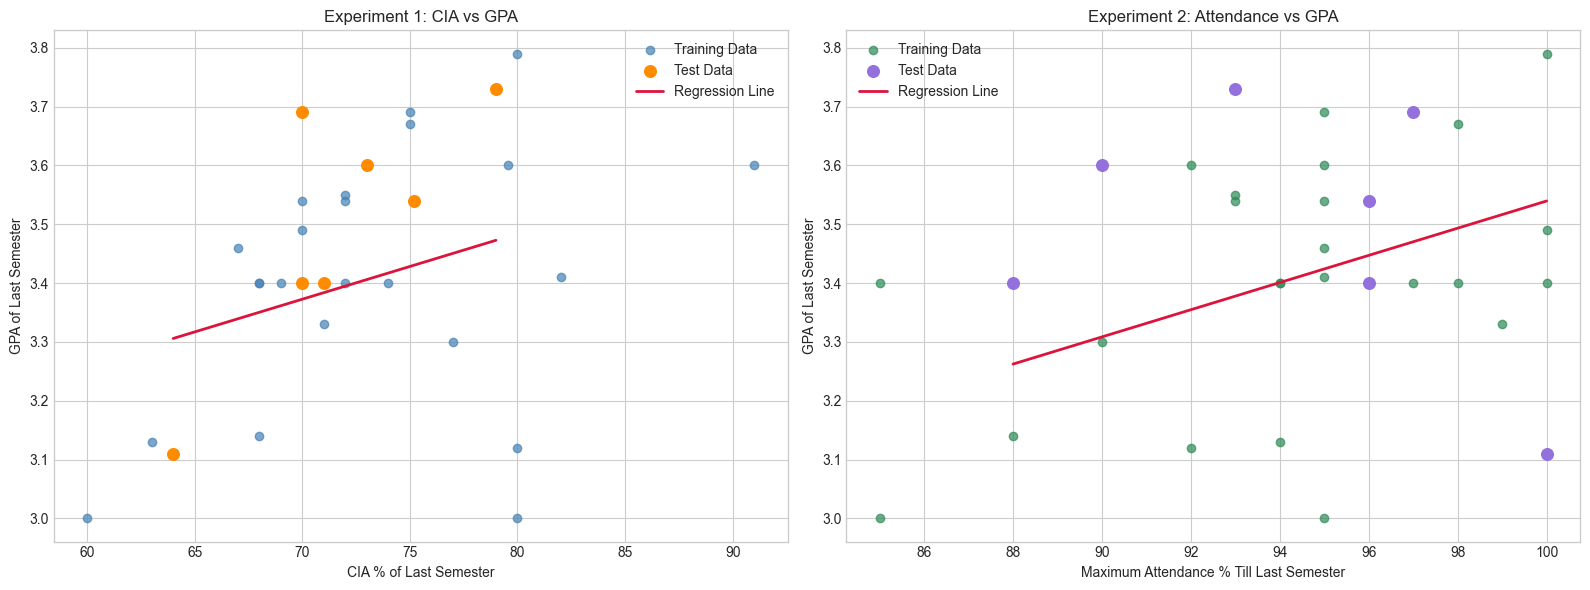

In [33]:
import matplotlib.pyplot as plt

# Graphs for both linear regression experiments using the variables already created above
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Experiment 1: CIA vs GPA
exp1_plot = pd.DataFrame({
    'CIA': x1test['Your CIA % of last semester'],
    'Actual GPA': y1test,
    'Predicted GPA': Y_pred_1
}).sort_values('CIA')

axes[0].scatter(
    x1train['Your CIA % of last semester'], y1train,
    color='steelblue', alpha=0.7, label='Training Data'
)
axes[0].scatter(
    x1test['Your CIA % of last semester'], y1test,
    color='darkorange', s=70, label='Test Data'
)
axes[0].plot(
    exp1_plot['CIA'], exp1_plot['Predicted GPA'],
    color='crimson', linewidth=2, label='Regression Line'
)
axes[0].set_title('Experiment 1: CIA vs GPA')
axes[0].set_xlabel('CIA % of Last Semester')
axes[0].set_ylabel('GPA of Last Semester')
axes[0].legend()

# Experiment 2: Attendance vs GPA
exp2_plot = pd.DataFrame({
    'Attendance': x2test['Your maximum attendance % till last semester'],
    'Actual GPA': y2test,
    'Predicted GPA': Y_pred_2
}).sort_values('Attendance')

axes[1].scatter(
    x2train['Your maximum attendance % till last semester'], y2train,
    color='seagreen', alpha=0.7, label='Training Data'
)
axes[1].scatter(
    x2test['Your maximum attendance % till last semester'], y2test,
    color='mediumpurple', s=70, label='Test Data'
)
axes[1].plot(
    exp2_plot['Attendance'], exp2_plot['Predicted GPA'],
    color='crimson', linewidth=2, label='Regression Line'
)
axes[1].set_title('Experiment 2: Attendance vs GPA')
axes[1].set_xlabel('Maximum Attendance % Till Last Semester')
axes[1].set_ylabel('GPA of Last Semester')
axes[1].legend()

plt.tight_layout()
plt.show()


In [34]:
import pickle
from sklearn.linear_model import LinearRegression

# Parameter saving task using the existing variables from Experiment 1
pickle_model = LinearRegression()
pickle_model.fit(x1train, y1train)

parameters = {
    'slope': pickle_model.coef_[0],
    'intercept': pickle_model.intercept_
}

file_name = 'linear_regression_weights.pkl'

# Save parameters into Pickle file
with open(file_name, 'wb') as file:
    pickle.dump(parameters, file)

print('Saved parameters to', file_name)
print('Slope:', parameters['slope'])
print('Intercept:', parameters['intercept'])

# Load the Pickle file
with open(file_name, 'rb') as file:
    loaded_parameters = pickle.load(file)

print('\nLoaded Parameters')
print('Slope:', loaded_parameters['slope'])
print('Intercept:', loaded_parameters['intercept'])

# Use loaded parameters for prediction
sample_x = x1test.iloc[0, 0]
predicted_gpa = (loaded_parameters['slope'] * sample_x) + loaded_parameters['intercept']

print('\nPrediction Using Loaded Parameters')
print('CIA Input:', sample_x)
print('Predicted GPA:', predicted_gpa)


Saved parameters to linear_regression_weights.pkl
Slope: 0.011126051758389743
Intercept: 2.5937416949399195

Loaded Parameters
Slope: 0.011126051758389743
Intercept: 2.5937416949399195

Prediction Using Loaded Parameters
CIA Input: 75.2
Predicted GPA: 3.4304207871708283
